In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set legacy Keras mode BEFORE any TensorFlow/Keras imports
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras as keras  # Use tf_keras for TFMOT compatibility
from tf_keras import layers
from tf_keras.preprocessing.image import ImageDataGenerator
import tensorflow_model_optimization as tfmot
import tensorflow.lite as tflite

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("CPUs:", tf.config.list_physical_devices("CPU"))


TF version: 2.16.1
GPUs: []
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATASET_PATH = "D:/waste_project/waste-classification-system-II/resized_dataset"

img_size = (96, 96)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="rgb"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="rgb"
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 8407 files belonging to 9 classes.
Using 6726 files for training.
Found 8407 files belonging to 9 classes.
Using 1681 files for validation.


In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])


In [4]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet",
    minimalistic=True
)

base_model.trainable = False


C:\Users\Asghar\anaconda3\envs\waste_env\lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


2128592/2128592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
inputs = keras.Input(shape=(96, 96, 3))
x = tf.keras.applications.mobilenet_v3.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)


In [8]:
inputs = keras.Input(shape=(96, 96, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="mobilenetv3_small_96x96_waste")
model.summary()


Model: "mobilenetv3_small_96x96_waste"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MobileNetV3Small (Functional)        │ (None, 3, 3, 576)           │         441,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 576)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │           5,193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 446,193 (1.70 MB)

 Trainable params: 5,193 (20.29 KB)

 Non-trainable params: 441,000 (1.68 MB)

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - accuracy: 0.3293 - loss: 2.2652 - val_accuracy: 0.5342 - val_loss: 1.3476
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.4737 - loss: 1.6080 - val_accuracy: 0.5842 - val_loss: 1.1855
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.5241 - loss: 1.3955 - val_accuracy: 0.6151 - val_loss: 1.0996
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.5543 - loss: 1.3174 - val_accuracy: 0.6478 - val_loss: 1.0726
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.5630 - loss: 1.2737 - val_accuracy: 0.6270 - val_loss: 1.0452
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.5795 - loss: 1.2286 - val_accuracy: 0.6496 - val_loss: 1.0296
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.5825 - loss: 1.2137 - val_accuracy: 0.6443 - val_loss: 1.0278
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.5849 - loss: 1.1978 - 

In [15]:
base_model.trainable = True

# Optional: freeze early layers (helps stability)
for layer in base_model.layers[:40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.5195 - loss: 1.3828 - val_accuracy: 0.6157 - val_loss: 1.0649
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.5895 - loss: 1.1719 - val_accuracy: 0.6407 - val_loss: 1.0102
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.6148 - loss: 1.1025 - val_accuracy: 0.6663 - val_loss: 0.9471
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.6348 - loss: 1.0593 - val_accuracy: 0.6746 - val_loss: 0.9173
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.6539 - loss: 1.0004 - val_accuracy: 0.6764 - val_loss: 0.8957
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.6564 - loss: 0.9700 - val_accuracy: 0.7008 - val_loss: 0.8544
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.6676 - loss: 0.9381 - val_accuracy: 0.7079 - val_loss: 0.8373
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.6866 - loss: 0.8926 - 

In [15]:
history.history["accuracy"][-1], history.history["val_accuracy"][-1]


(0.6458519101142883, 0.6876859068870544)

In [16]:
final_train_acc = history_ft.history["accuracy"][-1]
final_val_acc = history_ft.history["val_accuracy"][-1]
print(final_train_acc, final_val_acc)


0.7033898234367371 0.7275431156158447


In [32]:
model.save("mobilenetv3_small_96x96_float.keras")


In [33]:
model = keras.models.load_model("mobilenetv3_small_96x96_float.keras")
loss, acc = model.evaluate(val_ds)
print("Validation accuracy:", acc)


53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.7275 - loss: 0.7696
Validation accuracy: 0.7275431156158447


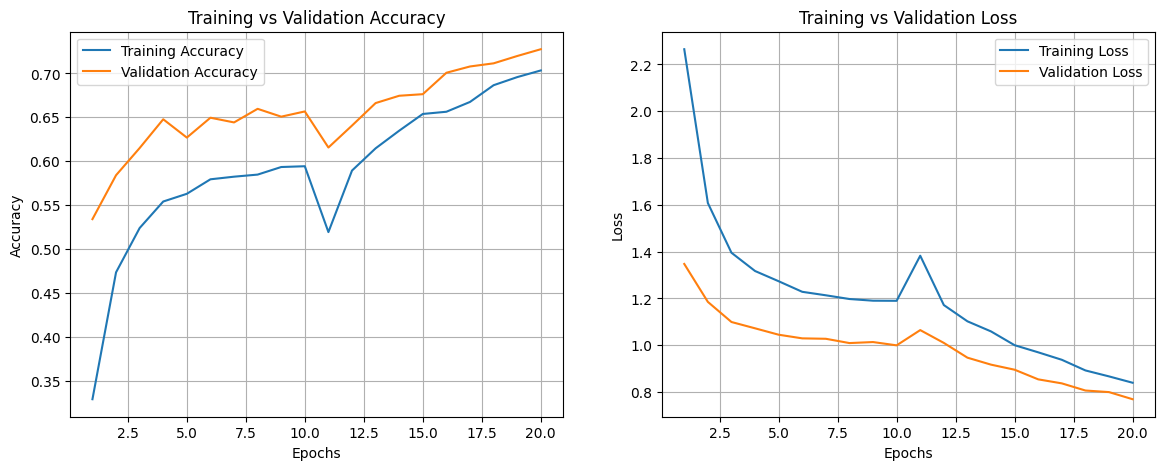

In [21]:
import matplotlib.pyplot as plt

# Combine histories
acc = history.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]

loss = history.history["loss"] + history_ft.history["loss"]
val_loss = history.history["val_loss"] + history_ft.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


In [22]:
import tensorflow_model_optimization as tfmot

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.50,   # 50% pruning
        begin_step=0,
        end_step=1000
    )
}


### Load the saved model

In [34]:
model = keras.models.load_model("mobilenetv3_small_96x96_float.keras")


In [35]:
def representative_data_gen():
    for images, _ in train_ds.take(100):
        yield [tf.cast(images, tf.float32)]


In [32]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


In [25]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("TF version:", tf.__version__)
print("TFLite converter:", hasattr(tf.lite, "TFLiteConverter"))
print("INT8 ops:", tf.lite.OpsSet.TFLITE_BUILTINS_INT8)
print("Pruning available:", hasattr(tfmot.sparsity.keras, "prune_low_magnitude"))


TF version: 2.16.1
TFLite converter: True
INT8 ops: TFLITE_BUILTINS_INT8
Pruning available: True


In [36]:
import tensorflow_model_optimization as tfmot
model = tfmot.sparsity.keras.strip_pruning(model)


ValueError: ('Expected model to be a `keras.Model` instance but got: ', <Functional name=mobilenetv3_small_96x96_waste, built=True>)

In [39]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

In [40]:


converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("mobilenetv3_small_96x96_int8.tflite", "wb") as f:
    f.write(tflite_model)

AttributeError: 'Functional' object has no attribute '_get_save_spec'